<a href="https://colab.research.google.com/github/SanikaPatil1008/Deep_Learning/blob/main/Exp_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

Training started...

Epoch 1, Loss: 1.442, Train Acc: 48.52%, Test Acc: 56.43%
Epoch 2, Loss: 1.095, Train Acc: 61.20%, Test Acc: 62.35%
Epoch 3, Loss: 0.930, Train Acc: 67.22%, Test Acc: 65.79%
Epoch 4, Loss: 0.825, Train Acc: 71.00%, Test Acc: 67.93%
Epoch 5, Loss: 0.740, Train Acc: 73.98%, Test Acc: 67.92%

Training Finished!


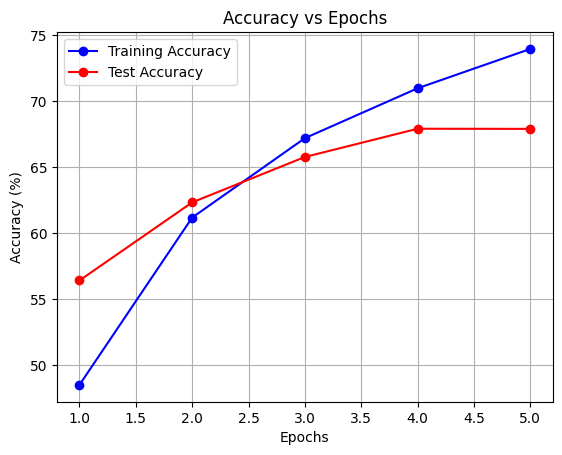

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data',
                                        train=True,
                                        download=True,
                                        transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data',
                                       train=False,
                                       download=True,
                                       transform=transform)

trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=64,
                                          shuffle=True)

testloader = torch.utils.data.DataLoader(testset,
                                         batch_size=64,
                                         shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')


# Step 2: CNN Architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 32 * 8 * 8)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x


# Initialize model
model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Step 3: Evaluation
train_acc_list = []
test_acc_list = []

print("Training started...\n")

for epoch in range(5):
    running_loss = 0.0
    correct = 0
    total = 0

    # TRAINING
    model.train()
    for inputs, labels in trainloader:
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Training accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    train_acc_list.append(train_acc)

    # TEST accuracy each epoch
    correct = 0
    total = 0
    model.eval()

    with torch.no_grad():
        for inputs, labels in testloader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    test_acc_list.append(test_acc)

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.3f}, "
          f"Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")

print("\nTraining Finished!")

import matplotlib.pyplot as plt

epochs = range(1, 6)

plt.plot(epochs, train_acc_list, 'b-o', label='Training Accuracy')
plt.plot(epochs, test_acc_list, 'r-o', label='Test Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)

plt.show()